In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py
import numpy as np
import json
from datetime import datetime

In [2]:
def projectDistZ(x1,x2,y1,y2,d12,z):
    mx = (x2-x1)/d12
    xProj = x1 + mx * z
    
    my = (y2-y1)/d12
    yProj = y1 + my * z
    
    return (xProj, yProj)

def get_theta_angles(x1, y1, x2, y2, d):
    import numpy as np
    thetaX = np.arctan((x2-x1)/d) #rad
    thetaY = np.arctan((y2-y1)/d) #rad
    return (thetaX, thetaY)


def file_loader(runs):
    from collections.abc import Iterable

    if not isinstance(runs, Iterable):
        runs = [runs]

    pos = []
    phs = []
    tmis = []
    qtots = []
    nclus = []
    info_pluss = []
    xinfos = []
    n_spill_list = []

    for run_number in runs:
        data_path = f'/eos/project/i/insulab-como/testBeam/TB_2025_06_T9_epBOOST/HDF5/run{run_number}.h5'
        with h5py.File(data_path, 'r', libver='latest', swmr=True) as hf:
            pos.append(np.array(hf['xpos']))
            phs.append(np.array(hf['digiPH']))
            tmis.append(np.array(hf['digiTime']))
            qtots.append(np.array(hf['qtot']))
            nclus.append(np.array(hf['nclu']))
            info_plus = np.array(hf['info_plus'])
            xinfo = np.array(hf['xinfo'])
            info_pluss.append(info_plus)
            xinfos.append(xinfo)

            n_spill = int(np.max(info_plus[:, 0]))
            n_spill_list.append(n_spill)
            print(f'Run {run_number} — N spill: {n_spill} — events: {len(hf["xpos"])} — evs/spill: {len(hf["xpos"]) / n_spill:.0f}')

    xpos = np.concatenate(pos, axis=0)
    ph = np.concatenate(phs, axis=0)
    tm = np.concatenate(tmis, axis=0)
    qtot = np.concatenate(qtots, axis=0)
    nclu = np.concatenate(nclus, axis=0)
    info_plus = np.concatenate(info_pluss, axis=0)
    xinfo = np.concatenate(xinfos, axis=0)

    logic_pos = (xpos[:, :6] > -1) & (xpos[:, :6] < 15)
    
    logic = logic_pos.all(axis = 1)
    xpos= xpos[logic]
    ph= ph[logic]
    tm= tm[logic]
    qtot= qtot[logic]
    nclu= nclu[logic]
    info_plus= info_plus[logic]
    xinfo= xinfo[logic]
    # Apply offsets
    xpos[:, 0] -= offset_x1
    xpos[:, 1] -= offset_y1
    xpos[:, 4] -= offset_x3
    xpos[:, 5] -= offset_y3

    x1 = xpos[:, 0]
    y1 = xpos[:, 1]
    x2 = xpos[:, 2]
    y2 = xpos[:, 3]
    x3 = xpos[:, 4]
    y3 = xpos[:, 5]

    Calibration = False
    if Calibration:
        q = -25.84
        m = 323.4
        ph[:, 2] = (ph[:, 2] - q) / m

    xcry, ycry = projectDistZ(x1, x2, y1, y2, d12, d1c)
    theta_x_in, theta_y_in = get_theta_angles(x1, y1, x2, y2, d12)
    theta_x_out, theta_y_out = get_theta_angles(xcry, ycry, x3, y3, dc3)

    ph_calo_photon = ph[:, 2]
    ph_cherry1 = ph[:, 0]

    total_spills = sum(n_spill_list)
    print(f"{runs} — TOTAL SPILLS: {total_spills} — TOTAL EVENTS: {len(x1)}")

    return xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
           theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo


In [3]:
# === OFFSET e DISTANZE ===
d12 = 330  # cm
d23 = 53.2 + 626  ##66.8
d1c = 330 + 53.2  # cm
dc3 = 626 ## 10.7 
d1calo = d1c + 779.2

offset_x1 = 0.107
offset_y1 = -2.21

# ## run number < 730360
# # offset_x3 =   0.459 --- 0.484
# # offset_y3 =   -2.031 --- -2.053
# # run number > 730359
offset_x3 =    1.125,
offset_y3 =   -2.797

## NC ALIGN
# offset_x1, offset_y1 = 0.17853857345868965, -2.733923881801258
# offset_x3, offset_y3 = 0.9931285159961187, -1.9627562570988997


range_chamber = ((0,10),(0,10))
bins2d = (100,100)
mycmap = 'jet'

opt_hist = {'histtype': 'step', 'lw': 1.5, 'alpha': 0.8}
opts_2d = { "cmap" : mycmap, "bins" : bins2d} # "norm" : mpl.colors.LogNorm()}

th_cherry1 = 7
th_cherry2 = 20



In [4]:
with open('multiple_run-6GeV.json', 'r') as file:
    run_config = json.load(file)

scan_number = run_config.get("scan_number") 
label_scan = run_config.get("scan_labels")
ora_attuale = datetime.now().time()
print(f"Run numbers: {scan_number} -- {label_scan} -- ultimo aggiornamento {ora_attuale.strftime('%H:%M:%S')}")

Run numbers: [730245, 730224, 730247] -- ['Axis 6GeV', 'Amorphous like 6GeV', 'Conventional 6GeV'] -- ultimo aggiornamento 11:02:24


In [5]:
theta_crit = 9999999999
if any(run in [730224,730245,730247,730271] for run in scan_number): ## add 6GeV runs
    theta_crit = np.sqrt((2*887/(6*1e9))) ##rad
if any(run in [730250,730251,730253] for run in scan_number): ## add 2.866GeV runs
    theta_crit = np.sqrt((2*887/(2.86*1e9))) ##rad

CutTheta = False

if CutTheta == True:
    theta_cut = theta_crit
else:
    theta_cut = 100000000000
print(f'theta cut: ± {theta_cut*1e6:.2f} urad')

theta cut: ± 100000000000000000.00 urad


Run 730245 — N spill: 2860 — events: 274725 — evs/spill: 96
[730245] — TOTAL SPILLS: 2860 — TOTAL EVENTS: 271623
Run 730245: Δx = 0.500 cm, Δy = 0.500 cm, Area = 0.250 cm²

Run 730224 — N spill: 1334 — events: 194507 — evs/spill: 146
[730224] — TOTAL SPILLS: 1334 — TOTAL EVENTS: 192340
Run 730224: Δx = 0.500 cm, Δy = 0.500 cm, Area = 0.250 cm²

Run 730247 — N spill: 710 — events: 76622 — evs/spill: 108
[730247] — TOTAL SPILLS: 710 — TOTAL EVENTS: 75721
Run 730247: Δx = 0.500 cm, Δy = 0.500 cm, Area = 0.250 cm²



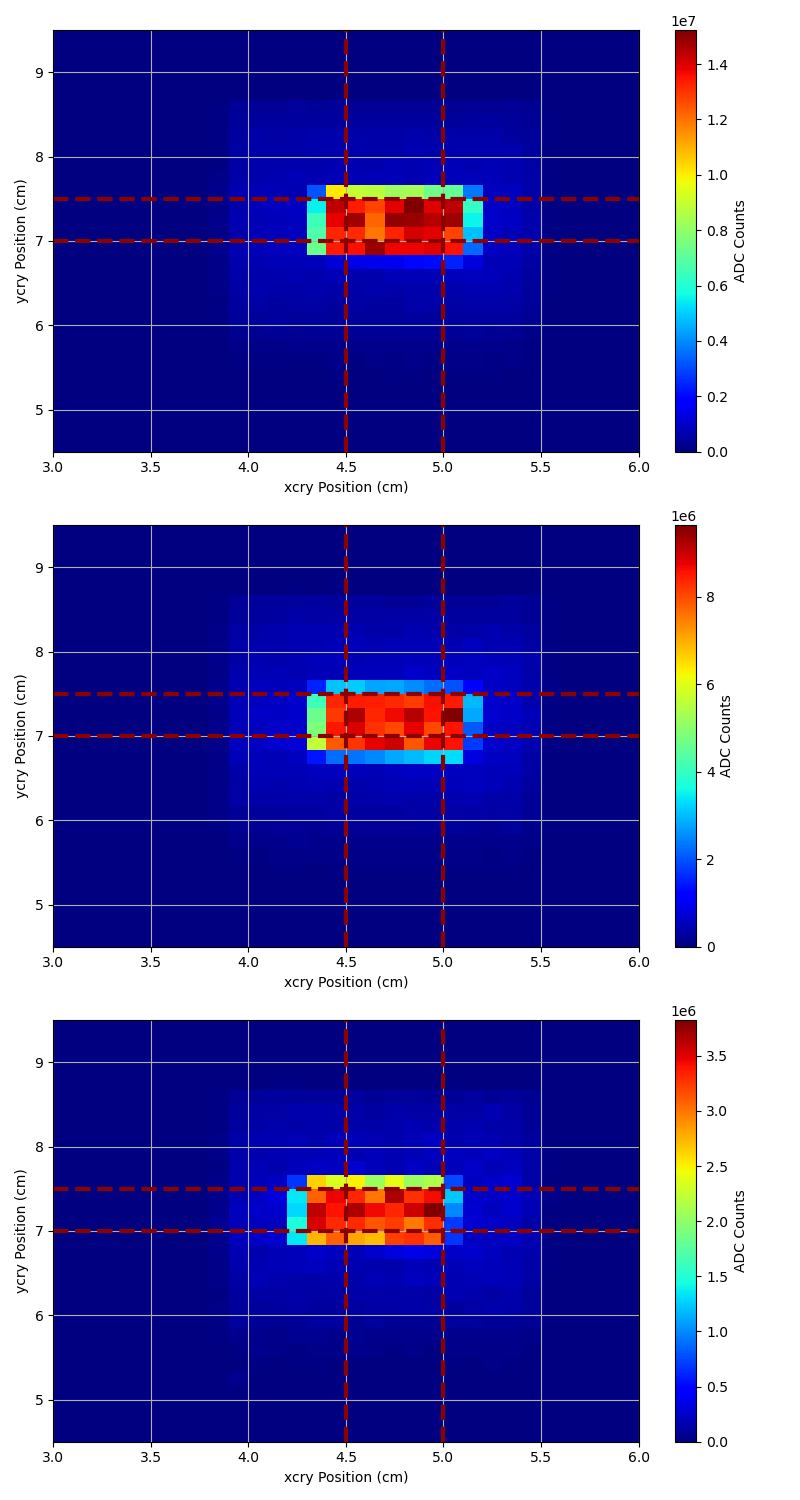

In [6]:
# Define cuts depending on scan_number content
cuts = {}
# if any(run in [730245, 730224, 730247,730250,730251,730253] for run in scan_number): 
#     cuts = { 
#         730245 : {'x_cry_cut': [4.7, 5.2], 'y_cry_cut': [4.65, 5.15]},
#         730224 : {'x_cry_cut': [4.7, 5.2], 'y_cry_cut': [4.65, 5.15]},
#         730247 : {'x_cry_cut': [4.6, 5.1], 'y_cry_cut': [4.7, 5.2]},
#         730250: {'x_cry_cut': [4.6, 5.1], 'y_cry_cut': [4.7, 5.2]},
#         730251: {'x_cry_cut': [4.6, 5.1], 'y_cry_cut': [4.7, 5.2]},
#         730253: {'x_cry_cut': [4.7, 5.2], 'y_cry_cut': [4.65, 5.15]}
#     }
# else:
#     for run in scan_number:
        # cuts[run] = {"x_cry_cut": [4.5, 5],"y_cry_cut": [7, 7.5],}
for run in scan_number:
    cuts[run] = {"x_cry_cut": [4.5, 5],"y_cry_cut": [7, 7.5],}

# Plotting
fig, ax = plt.subplots(len(scan_number), figsize=(8, 5*len(scan_number)))
if len(scan_number) == 1:
    ax = [ax]  # Ensure ax is always a list

for j, run in enumerate(scan_number):
    xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
    theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)

    mask = (ph_cherry1 > th_cherry1) & (((theta_x_in)**2 + (theta_y_in)**2)<theta_cut)
    hh_x = ax[j].hist2d(
        xcry[mask], ycry[mask],
        range=((3, 6), (4.5 ,9.5 )),
        weights=qtot[:, 0][mask],
        cmap=mycmap, bins=30
    )
    ax[j].set_xlabel('xcry Position (cm)')
    ax[j].set_ylabel('ycry Position (cm)')
    ax[j].grid()

    x_cry_cut = cuts[run]['x_cry_cut']
    y_cry_cut = cuts[run]['y_cry_cut']

    # Print cut dimensions
    dx = x_cry_cut[1] - x_cry_cut[0]
    dy = y_cry_cut[1] - y_cry_cut[0]
    print(f"Run {run}: Δx = {dx:.3f} cm, Δy = {dy:.3f} cm, Area = {dx*dy:.3f} cm²\n")

    ax[j].axvline(x=x_cry_cut[0], color='darkred', linestyle='--', lw = 3)
    ax[j].axvline(x=x_cry_cut[1], color='darkred', linestyle='--', lw = 3)
    ax[j].axhline(y=y_cry_cut[0], color='darkred', linestyle='--', lw = 3)
    ax[j].axhline(y=y_cry_cut[1], color='darkred', linestyle='--', lw = 3)

    plt.colorbar(hh_x[3], ax=ax[j], label='ADC Counts')


plt.tight_layout()
plt.show()


Run 730245 — N spill: 2860 — events: 274725 — evs/spill: 96
[730245] — TOTAL SPILLS: 2860 — TOTAL EVENTS: 271623
Run 730224 — N spill: 1334 — events: 194507 — evs/spill: 146
[730224] — TOTAL SPILLS: 1334 — TOTAL EVENTS: 192340
Run 730247 — N spill: 710 — events: 76622 — evs/spill: 108
[730247] — TOTAL SPILLS: 710 — TOTAL EVENTS: 75721


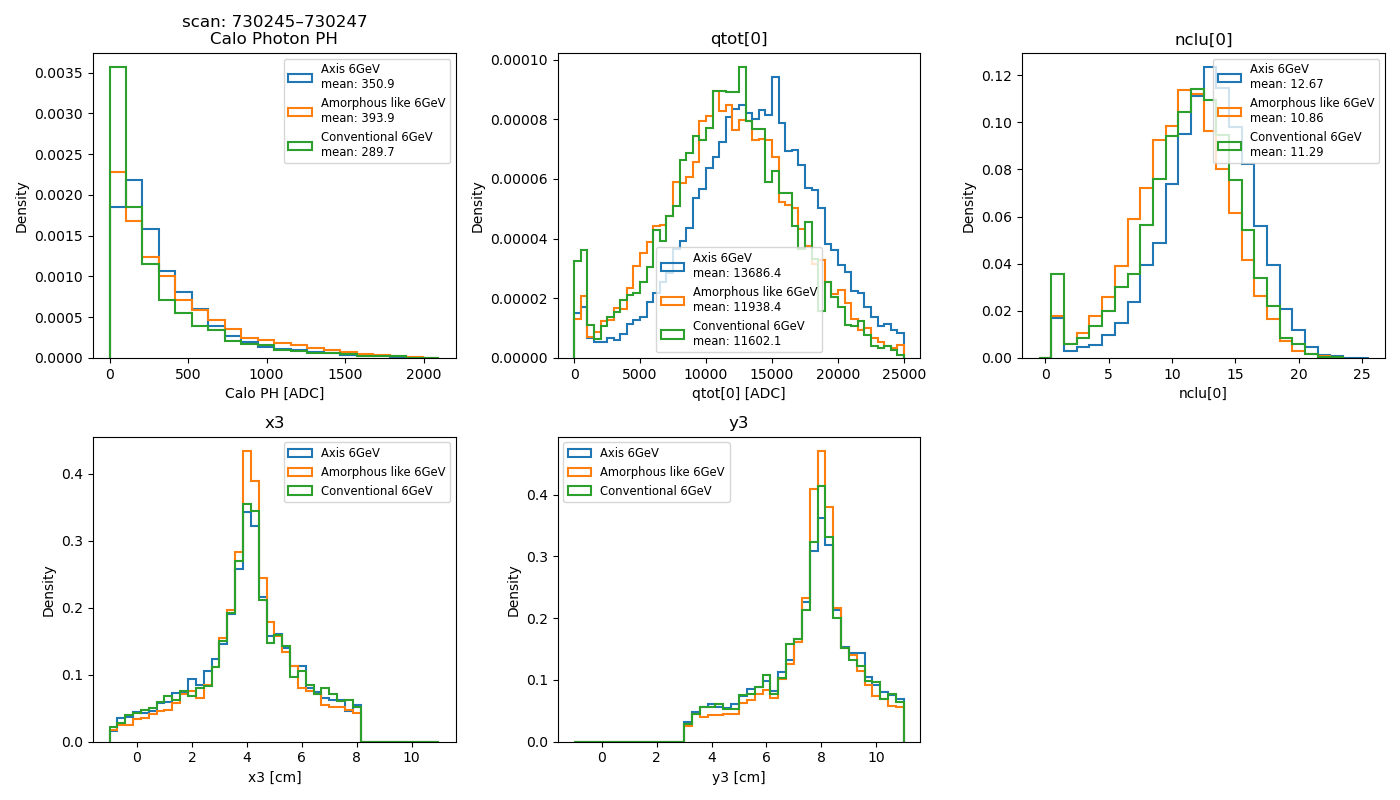

In [7]:
isrot = False
iscrad = True
opt_hist = dict(histtype='step', linewidth=1.5)

fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axs = axs.flatten()  # Makes indexing easier (axs[0] to axs[5])

means_nclu3 ={}
means_qtot3={}
for j, run in enumerate(scan_number):
    xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
    theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo = file_loader(run)

    x_cry_cut = cuts[run]['x_cry_cut']
    y_cry_cut = cuts[run]['y_cry_cut']

    dx = x_cry_cut[1] - x_cry_cut[0]
    dy = y_cry_cut[1] - y_cry_cut[0]
    # print(f"Run {run}: Δx = {dx:.3f} cm, Δy = {dy:.3f} cm, Area = {dx*dy:.3f} cm²")

    scan_angle = xinfo[:, 1] if iscrad else xinfo[:, 0]
    unique_steps = np.unique(scan_angle)
    # print(f'Run {run}: unique step values {unique_steps}')

    for step in unique_steps:
        logi = (ph_cherry1 > th_cherry1) & \
               (scan_angle == step) & \
               (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) & \
               (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) & \
               (((theta_x_in)**2 + (theta_y_in)**2)<theta_cut)

        if np.sum(logi) == 0:
            continue

        label = f'{label_scan[j]}'
        axs[0].hist(ph_calo_photon[logi], bins=20, range=(0, 2100), label=f'{label}\nmean: {np.mean(ph_calo_photon[logi]):.1f}', density=True, **opt_hist)
        axs[1].hist(qtot[:, 0][logi], bins=50, range=(0, 25000), label=f'{label}\nmean: {np.mean(qtot[:, 0][logi]):.1f}', density=True, **opt_hist)
        axs[2].hist(nclu[:, 0][logi], bins=np.arange(-0.5,round(np.max(nclu[:,0]))+0.5, 1), label=f'{label}\nmean: {np.mean(nclu[:, 0][logi]):.2f}', density=True, **opt_hist)
        axs[3].hist(x3[logi], bins=42, range=(-1,11), label=label, density=True, **opt_hist)
        axs[4].hist(y3[logi], bins=42, range=(-1,11), label=label, density=True, **opt_hist)

        means_nclu3[label] = np.mean(nclu[:, 0][logi & nclu[:, 0]>0])
        means_qtot3[label] = np.mean(qtot[:, 0][logi & nclu[:, 0]>0])

# Titoli
axs[0].set_title(f'scan: {scan_number[0]}–{scan_number[-1]}\nCalo Photon PH')
axs[1].set_title('qtot[0]')
axs[2].set_title('nclu[0]')
axs[3].set_title('x3')
axs[4].set_title('y3')

# Assi e scala log
labels = ['Calo PH [ADC]', 'qtot[0] [ADC]', 'nclu[0]', 'x3 [cm]', 'y3 [cm]']
for j in range(5):
    axs[j].set_xlabel(labels[j])
    axs[j].set_ylabel('Density')
    # axs[j].set_yscale('log')
    axs[j].legend(fontsize='small')

axs[5].axis('off')  # Rimuove subplot vuoto (2x3 layout)

plt.tight_layout()
plt.show()

In [8]:
# 730386 --> e+
# [730385,730378, 730384] --> e- 

### FULL 2.86 ###
compare_run = [[730385,730378, 730384],[730379,730383],[730386,730406,730414],[730388,730405]]
compare_labels = ['e- 2.86 axis', 'e- 2.86 amorphous','e+ 2.86 axis','e+ 2.86 amorphous'] 
colors = ['blue', 'black','hotpink', 'darkgreen']
Energy = 2.86
### ### ###
### 1 GeV ###
# compare_run = [730407 ,730408]
# compare_labels = ['e- 1 axis','e- 1 amorphous'] 
# colors = ['red','black']
# Energy= 1 
### ### ###
### 6 GeV ###
# compare_run = [730403,730404,730409 ,730410 ]
# compare_labels = ['e- 6 axis','e- 6 amorphous','e+ 6 amorphous','e+ 6 axis' ] 
# colors = ['blue', 'black', 'red', 'orange','hotpink', 'brown']
# Energy= 6
# ### ### ###

# ### e+ ###
# compare_run = [[730386,730406],[730388,730405]]
# compare_labels = ['e+ 2.86 axis','e+ 2.86 amorphous', ] 
# colors = ['hotpink', 'darkgreen']
# ### ## ###


## e- ###
# compare_run = [[730385,730378, 730384],[730379,730383],730389,730390,730403,730404 ]
# compare_labels = ['e- 2.86 axis', 'e- 2.86 amorphous','e- 2.86 +1.5TC Crad','e- 2.86 +2TC Rot','e- 6 axis','e- 6 amorphous' ] 
# compare_run = [730403,730404 ]
# compare_labels = ['e- 6 axis','e- 6 amorphous' ] 
# compare_run = [[730385,730378, 730384],[730379,730383]]
# compare_labels = ['e- 2.86 axis', 'e- 2.86 amorphous1','e- 2.86 amorphous2'] 
# colors = ['blue', 'black', 'red', 'orange','hotpink', 'brown']
### ## ###


In [9]:
# for j, run_list in enumerate(compare_run):

#     fig, axs = plt.subplots(2, 3, figsize=(12, 10))
#     axs = axs.flatten()

#     # === Load all runs in the group ===
#     (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
#      theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
#      info_plus, xinfo) = file_loader(run_list)

#     # === Plot 2D histograms ===
#     h0 = axs[0].hist2d(x1, x2, bins=100, range=((0,10),(0,10)), cmap=mycmap)
#     axs[0].set_title('x1 vs x2')
#     plt.colorbar(h0[3], ax=axs[0])

#     h1 = axs[1].hist2d(x2, x3, bins=100, range=((0,10),(0,10)), cmap=mycmap)
#     axs[1].set_title('x2 vs x3')
#     plt.colorbar(h1[3], ax=axs[1])

#     h2 = axs[2].hist2d(x3, x1, bins=100, range=((0,10),(0,10)), cmap=mycmap)
#     axs[2].set_title('x3 vs x1')
#     plt.colorbar(h2[3], ax=axs[2])

#     h3 = axs[3].hist2d(y1, y2, bins=100, range=((0,10),(0,10)), cmap=mycmap)
#     axs[3].set_title('y1 vs y2')
#     plt.colorbar(h3[3], ax=axs[3])

#     h4 = axs[4].hist2d(y2, y3, bins=100, range=((0,10),(0,10)), cmap=mycmap)
#     axs[4].set_title('y2 vs y3')
#     plt.colorbar(h4[3], ax=axs[4])

#     h5 = axs[5].hist2d(y3, y1, bins=100, range=((0,10),(0,10)), cmap=mycmap)
#     axs[5].set_title('y3 vs y1')
#     plt.colorbar(h5[3], ax=axs[5])

#     for ax in axs:
#         ax.set_xlabel('cm')
#         ax.set_ylabel('cm')

#     fig.suptitle(f'Run group {j+1}: Correlazioni tra coordinate')
#     plt.tight_layout()
#     plt.show()


Run 730385 — N spill: 212 — events: 18204 — evs/spill: 86
Run 730378 — N spill: 103 — events: 7783 — evs/spill: 76
Run 730384 — N spill: 796 — events: 69263 — evs/spill: 87
[730385, 730378, 730384] — TOTAL SPILLS: 1111 — TOTAL EVENTS: 95209
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730379 — N spill: 166 — events: 8032 — evs/spill: 48
Run 730383 — N spill: 626 — events: 40935 — evs/spill: 65
[730379, 730383] — TOTAL SPILLS: 792 — TOTAL EVENTS: 48940
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730386 — N spill: 105 — events: 8893 — evs/spill: 85
Run 730406 — N spill: 213 — events: 22318 — evs/spill: 105
Run 730414 — N spill: 164 — events: 16739 — evs/spill: 102
[730386, 730406, 730414] — TOTAL SPILLS: 482 — TOTAL EVENTS: 47933
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730388 — N spill: 106 — events: 9470 — evs/spill: 89
Run 730405 — N spill: 224 — events: 22214 — evs/spill: 99
[730388, 730405] — TOTAL SPILL

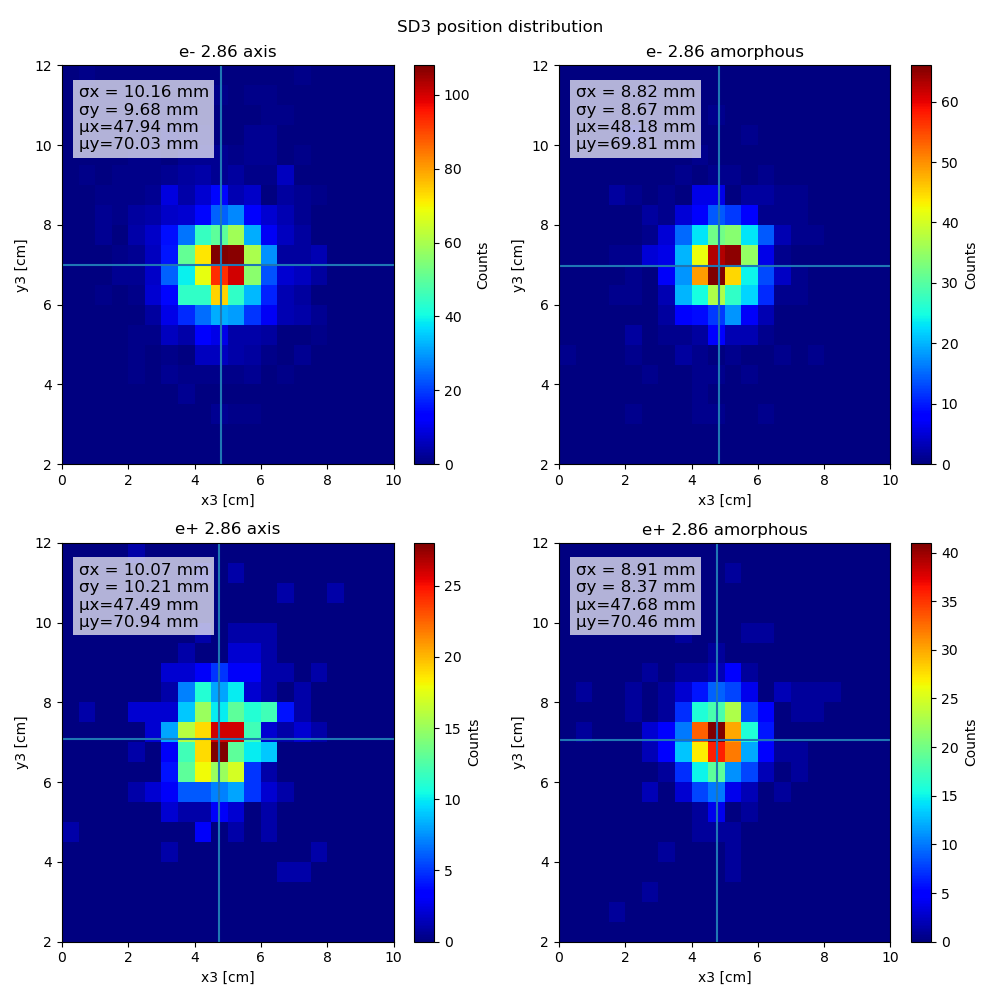

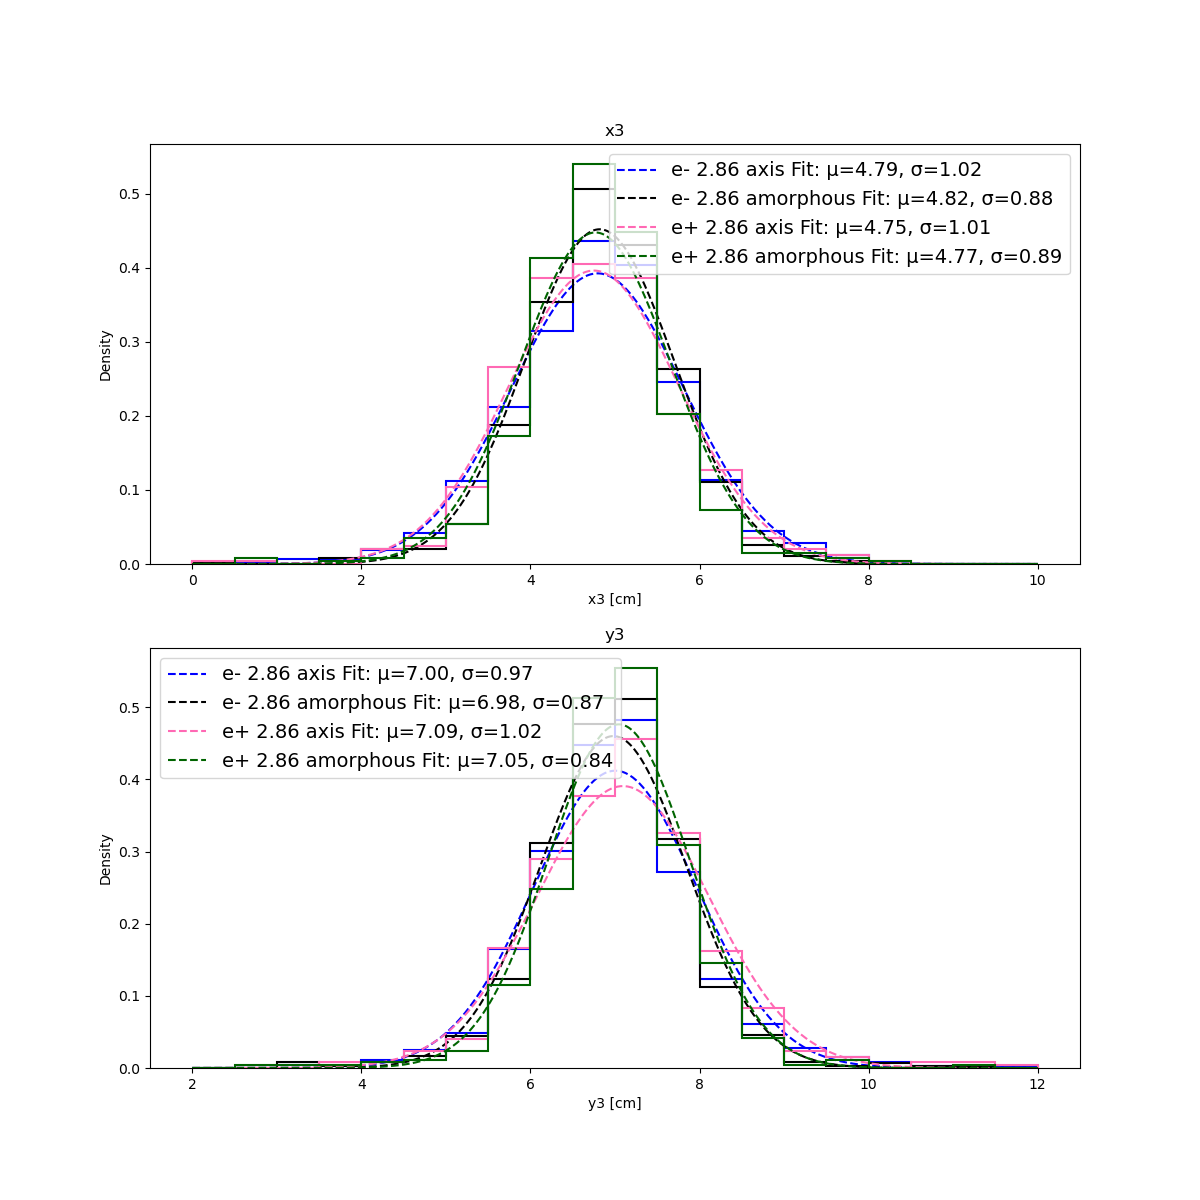

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import math



###############
bins_pos = 20
###############

opt_hist = dict(histtype='step', linewidth=1.5)

fig, axs = plt.subplots(2, figsize=(12, 12))
axs = axs.flatten()

ncol = 2
nrow = math.ceil(len(compare_run) / ncol)
fig2, ax2 = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow))
fig2.suptitle('SD3 position distribution')
ax2 = ax2.flatten()


means_nclu3 = {}
means_qtot3 = {}
events = {}

for j, run_list in enumerate(compare_run):
    label = compare_labels[j]

    # === Load all runs in the group ===
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run_list)

    # === Get cuts ===
    x_cry_cut = [4.4, 5.1]
    y_cry_cut = [6.9, 7.5]
    theta_cut = np.sqrt(2 * 887 / (np.abs(Energy) * 1e9))  # rad]
    print(f'Cuts: x {x_cry_cut} -- y {y_cry_cut} -- theta {theta_cut}')
    # === Selection mask ===
    logi = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2)) &
        (nclu[:, 0] == 1) &  (nclu[:, 1] == 1)
    )
    events[label] = np.sum(logi)

    if np.sum(logi) == 0:
        continue

    color = colors[j]

    # === x3 ===
    x_data = x3[logi]
    axs[0].hist(x_data, bins=bins_pos, range=(0, 10), density=True,
                color=color, **opt_hist)

    mu_x, sigma_x = norm.fit(x_data)
    x_range = np.linspace(0, 10, 500)
    axs[0].plot(x_range, norm.pdf(x_range, mu_x, sigma_x),
                linestyle='--', color=color,
                label=f"{label} Fit: μ={mu_x:.2f}, σ={sigma_x:.2f}")

    # === y3 ===
    y_data = y3[logi]
    axs[1].hist(y_data, bins=bins_pos, range=(2,12), density=True,
                color=color, **opt_hist)

    mu_y, sigma_y = norm.fit(y_data)
    y_range = np.linspace(2,12, 500)
    axs[1].plot(y_range, norm.pdf(y_range, mu_y, sigma_y),
                linestyle='--', color=color,
                label=f"{label} Fit: μ={mu_y:.2f}, σ={sigma_y:.2f}")


    h2d = ax2[j].hist2d(x_data, y_data, bins=bins_pos, range=((0, 10), (2,12)), cmap=mycmap)
    ax2[j].set_title(label)
    ax2[j].set_xlabel('x3 [cm]')
    ax2[j].set_ylabel('y3 [cm]')
    plt.colorbar(h2d[3], ax=ax2[j], label='Counts')

    ax2[j].axvline(mu_x)
    ax2[j].axhline(mu_y)
    ax2[j].text(
    0.05, 0.95,
    f"σx = {sigma_x*10:.2f} mm\nσy = {sigma_y*10:.2f} mm\nμx={mu_x*1e1:.2f} mm\nμy={mu_y*1e1:.2f} mm",
    transform=ax2[j].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
    )

# === Titles and labels ===
axs[0].set_title('x3')
axs[1].set_title('y3')

labels = ['x3 [cm]', 'y3 [cm]']
for j in range(2):
    axs[j].set_xlabel(labels[j])
    axs[j].set_ylabel('Density')
    axs[j].legend(fontsize=14, loc='best')
    # axs[j].set_yscale('log')

plt.tight_layout()
plt.show()


Run 730385 — N spill: 212 — events: 18204 — evs/spill: 86
Run 730378 — N spill: 103 — events: 7783 — evs/spill: 76
Run 730384 — N spill: 796 — events: 69263 — evs/spill: 87
[730385, 730378, 730384] — TOTAL SPILLS: 1111 — TOTAL EVENTS: 95209
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730379 — N spill: 166 — events: 8032 — evs/spill: 48
Run 730383 — N spill: 626 — events: 40935 — evs/spill: 65
[730379, 730383] — TOTAL SPILLS: 792 — TOTAL EVENTS: 48940
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730386 — N spill: 105 — events: 8893 — evs/spill: 85
Run 730406 — N spill: 213 — events: 22318 — evs/spill: 105
Run 730414 — N spill: 164 — events: 16739 — evs/spill: 102
[730386, 730406, 730414] — TOTAL SPILLS: 482 — TOTAL EVENTS: 47933
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730388 — N spill: 106 — events: 9470 — evs/spill: 89
Run 730405 — N spill: 224 — events: 22214 — evs/spill: 99
[730388, 730405] — TOTAL SPILL

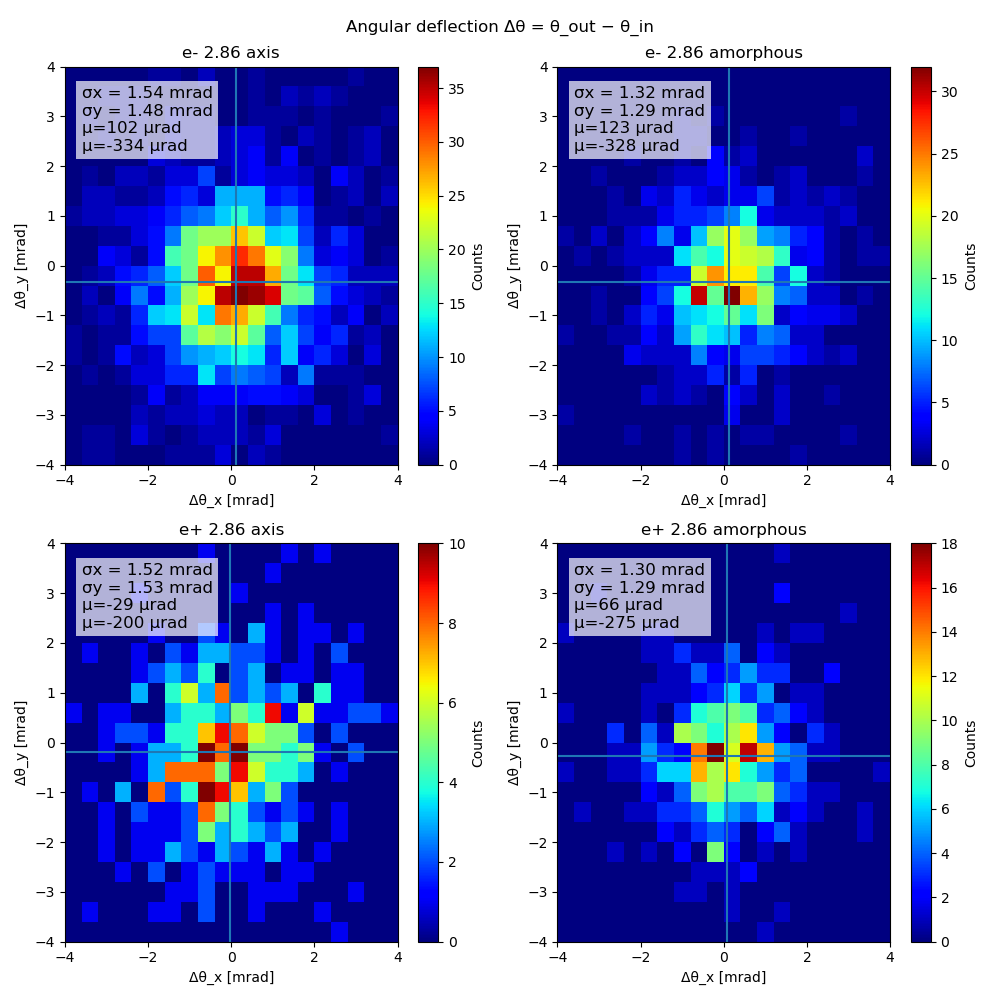

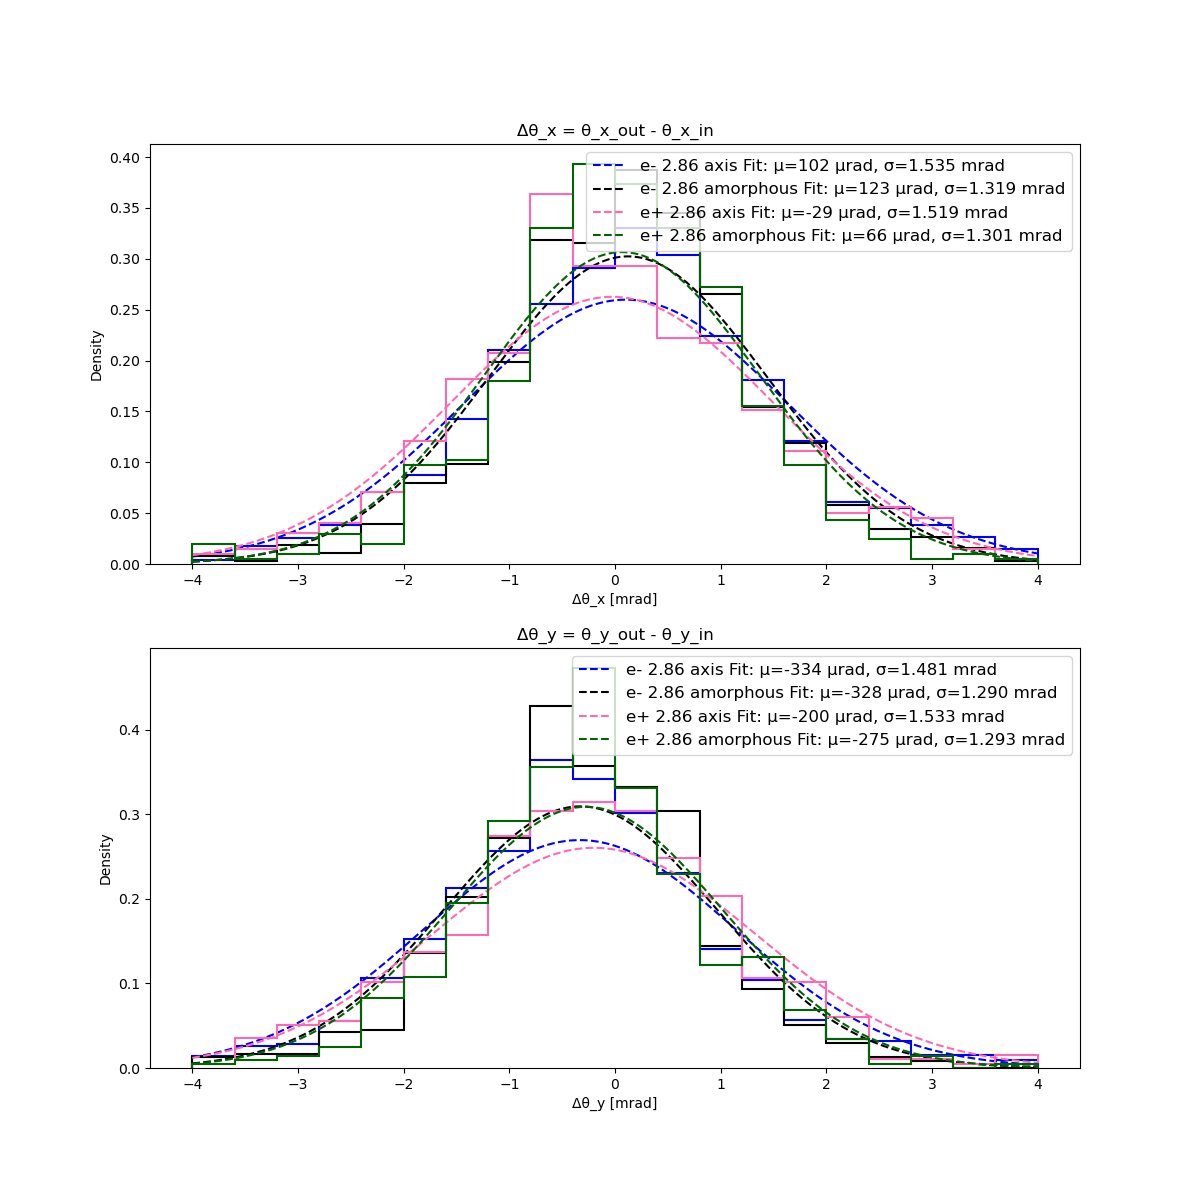

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import math

###############
bins_defl = 20
theta_lim = 4
###############


fig_dtheta, axs_dtheta = plt.subplots(2, figsize=(12, 12))
# fig_dtheta.suptitle(f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_deflection')
axs_dtheta = axs_dtheta.flatten()


ncol = 2
nrow = math.ceil(len(compare_run) / ncol)
fig_dtheta2, ax_dtheta2 = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow))
fig_dtheta2.suptitle('Angular deflection Δθ = θ_out − θ_in')
ax_dtheta2 = ax_dtheta2.flatten()

for j, run_list in enumerate(compare_run):
    label = compare_labels[j]


    # === Load data ===
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run_list)

    x_cry_cut = [4.4, 5.1]
    y_cry_cut = [6.9, 7.5]
    theta_cut = np.sqrt(2 * 887 / (np.abs(Energy) * 1e9))  # rad]
    print(f'Cuts: x {x_cry_cut} -- y {y_cry_cut} -- theta {theta_cut}')

    logi = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2)) &
        (nclu[:, 0] == 1) & (nclu[:, 1] == 1)
    )
    events[label] = np.sum(logi)

    if np.sum(logi) == 0:
        continue

    color = colors[j]

    # === Compute deflection in mrad ===
    dtheta_x = (theta_x_out[logi] - theta_x_in[logi]) * 1e3
    dtheta_y = (theta_y_out[logi] - theta_y_in[logi]) * 1e3

    # === Plot Δθ_x ===
    axs_dtheta[0].hist(dtheta_x, bins=bins_defl, range=(-theta_lim, theta_lim),
                       density=True, color=color, **opt_hist)
    mu_dx, sigma_dx = norm.fit(dtheta_x)
    x_range = np.linspace(-theta_lim, theta_lim, 500)
    axs_dtheta[0].plot(x_range, norm.pdf(x_range, mu_dx, sigma_dx),
                       linestyle='--', color=color,
                       label=f"{label} Fit: μ={mu_dx*1e3:.0f} μrad, σ={sigma_dx:.3f} mrad")

    # === Plot Δθ_y ===
    axs_dtheta[1].hist(dtheta_y, bins=bins_defl, range=(-theta_lim, theta_lim),
                       density=True, color=color, **opt_hist)
    mu_dy, sigma_dy = norm.fit(dtheta_y)
    y_range = np.linspace(-theta_lim, theta_lim, 500)
    axs_dtheta[1].plot(y_range, norm.pdf(y_range, mu_dy, sigma_dy),
                       linestyle='--', color=color,
                       label=f"{label} Fit: μ={mu_dy*1e3:.0f} μrad, σ={sigma_dy:.3f} mrad")

    # === Plot 2D histogram of deflections ===
    h2d = ax_dtheta2[j].hist2d(dtheta_x, dtheta_y, bins=bins_defl,
                               range=((-theta_lim, theta_lim), (-theta_lim, theta_lim)), cmap=mycmap)
    ax_dtheta2[j].set_title(label)
    ax_dtheta2[j].set_xlabel('Δθ_x [mrad]')
    ax_dtheta2[j].set_ylabel('Δθ_y [mrad]')    
    plt.colorbar(h2d[3], ax=ax_dtheta2[j], label='Counts')
    ax_dtheta2[j].axvline(mu_dx)
    ax_dtheta2[j].axhline(mu_dy)

    ax_dtheta2[j].text(
    0.05, 0.95,
    f"σx = {np.std(dtheta_x):.2f} mrad\nσy = {np.std(dtheta_y):.2f} mrad\nμ={np.mean(dtheta_x)*1e3:.0f} μrad\nμ={np.mean(dtheta_y)*1e3:.0f} μrad",
    transform=ax_dtheta2[j].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)
    
# === Labels and layout ===
axs_dtheta[0].set_title('Δθ_x = θ_x_out - θ_x_in')
axs_dtheta[1].set_title('Δθ_y = θ_y_out - θ_y_in')
axs_dtheta[0].set_xlabel('Δθ_x [mrad]')
axs_dtheta[1].set_xlabel('Δθ_y [mrad]')
axs_dtheta[0].set_ylabel('Density')
axs_dtheta[1].set_ylabel('Density')
axs_dtheta[0].legend(fontsize=12)
axs_dtheta[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


In [12]:
print(events)

{'e- 2.86 axis': 1922, 'e- 2.86 amorphous': 957, 'e+ 2.86 axis': 504, 'e+ 2.86 amorphous': 523}
